# BEBM MLP SiLU vs Sigmoid

Compare BEBM MLP trainings on binary MNIST: SiLU vs Sigmoid hidden activation.


In [59]:
from pathlib import Path
import contextlib

import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from rbms.dataset import load_dataset
from rbms.io import load_model, load_params
from rbms.utils import get_saved_updates
from rbms.plot import plot_mult_PCA
import rbms.EBM_binary.energies as binary_energies

plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.family"] = "STIXGeneral"
plt.rcParams.update({"font.size": 13})

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
ROOT = Path.cwd().resolve()
if ROOT.name != "rbms":
    ROOT = ROOT / "rbms"

device = "cuda:0" if torch.cuda.is_available() else "cpu"
dtype = torch.float32

train_dataset_name = str(ROOT / "data/MNIST_train.h5")
test_dataset_name = str(ROOT / "data/MNIST_test.h5")

MODEL_SPECS = {
    "BEBM MLP | SiLU": {
        "filename": str(ROOT / "pcd_trains/BEBM_MLP_SiLU_h500_DMALA100_lr1e-2_100k.h5"),
        "activation": torch.nn.SiLU,
    },
    "BEBM MLP | Sigmoid": {
        "filename": str(ROOT / "pcd_trains/BEBM_MLP_Sigmoid_h500_DMALA100_lr1e-2_100k.h5"),
        "activation": torch.nn.Sigmoid,
    },
}

# Use an earlier SiLU checkpoint for final diagnostics because the 100k checkpoint diverges.
FINAL_UPDATE_OVERRIDES = {
    "BEBM MLP | SiLU": 26915,
    "BEBM MLP | Sigmoid": None,
}

IMAGE_SHAPE = (28, 28)
PCA_POINT_SCALE = float(IMAGE_SHAPE[0])

print("device:", device)
missing_files = []
for label, spec in MODEL_SPECS.items():
    path = Path(spec["filename"])
    print(label, "->", path, "exists=" + str(path.exists()))
    if not path.exists():
        missing_files.append(path)

if missing_files:
    missing = "\n".join(str(path) for path in missing_files)
    raise FileNotFoundError(
        "Missing training archive(s). Rsync them into rbms/pcd_trains before running this notebook:\n"
        + missing
    )


device: cpu
BEBM MLP | SiLU -> /Users/aidan/Documents/Research_Internship/Code/rbms/pcd_trains/BEBM_MLP_SiLU_h500_DMALA100_lr1e-2_100k.h5 exists=True
BEBM MLP | Sigmoid -> /Users/aidan/Documents/Research_Internship/Code/rbms/pcd_trains/BEBM_MLP_Sigmoid_h500_DMALA100_lr1e-2_100k.h5 exists=True


## Load Data and Checkpoints


In [61]:
train_dataset, test_dataset = load_dataset(
    dataset_name=train_dataset_name,
    test_dataset_name=test_dataset_name,
    device=device,
    dtype=dtype,
)

train_visible = train_dataset.data.to(device=device, dtype=dtype)
num_visibles = train_dataset.get_num_visibles()

saved_updates_by_model = {
    label: get_saved_updates(spec["filename"])
    for label, spec in MODEL_SPECS.items()
}

for label, updates in saved_updates_by_model.items():
    print(label)
    print("  first update:", int(updates[0]))
    print("  last update: ", int(updates[-1]))
    print("  checkpoints: ", len(updates))


Reading dataset from /Users/aidan/Documents/Research_Internship/Code/rbms/data/MNIST_train.h5...
    Done
Reading dataset from /Users/aidan/Documents/Research_Internship/Code/rbms/data/MNIST_test.h5...
    Done
BEBM MLP | SiLU
  first update: 1
  last update:  100000
  checkpoints:  699
BEBM MLP | Sigmoid
  first update: 1
  last update:  100000
  checkpoints:  699


## Helpers

In [62]:
def selected_updates(updates, num_points):
    updates = np.asarray(updates)
    num_points = min(num_points, len(updates))
    indices = np.linspace(0, len(updates) - 1, num_points).round().astype(int)
    indices = np.unique(indices)
    return updates[indices]


def selected_updates_decades(updates):
    updates = np.asarray(updates)
    max_update = int(updates[-1])
    targets = [int(updates[0])]

    decade = 100
    while decade <= max_update:
        for multiplier in range(1, 10):
            target = multiplier * decade
            if target <= max_update:
                targets.append(target)
        decade *= 10

    targets.append(max_update)
    targets = np.unique(targets)

    selected = []
    for target in targets:
        index = np.argmin(np.abs(updates - target))
        selected.append(updates[index])
    return np.unique(selected)


class ActivationMLPEnergy(torch.nn.Module):
    def __init__(self, num_visibles, hidden_dim=256, num_layers=1, visible_field=None, activation=torch.nn.SiLU):
        super().__init__()
        self.num_visibles = num_visibles
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        if visible_field is None:
            visible_field = torch.zeros(num_visibles)
        self.visible_field = torch.nn.Parameter(visible_field.clone())

        layers = []
        in_dim = num_visibles
        for _ in range(num_layers):
            layers.append(torch.nn.Linear(in_dim, hidden_dim))
            layers.append(activation())
            in_dim = hidden_dim
        layers.append(torch.nn.Linear(in_dim, 1))
        self.net = torch.nn.Sequential(*layers)

    def forward(self, v):
        return self.net(v).view(-1) - v @ self.visible_field


@contextlib.contextmanager
def mlp_activation_restore_context(activation):
    original_mlp = binary_energies.MLPEnergy
    original_map = binary_energies.ENERGY_MAP.get("mlp")

    def factory(num_visibles, hidden_dim=256, num_layers=1, visible_field=None):
        return ActivationMLPEnergy(
            num_visibles=num_visibles,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            visible_field=visible_field,
            activation=activation,
        )

    binary_energies.MLPEnergy = factory
    binary_energies.ENERGY_MAP["mlp"] = factory
    try:
        yield
    finally:
        binary_energies.MLPEnergy = original_mlp
        binary_energies.ENERGY_MAP["mlp"] = original_map


def load_params_with_activation(label, update):
    spec = MODEL_SPECS[label]
    with mlp_activation_restore_context(spec["activation"]):
        return load_params(spec["filename"], int(update), device=device, dtype=dtype)


def load_model_with_activation(label, update):
    spec = MODEL_SPECS[label]
    with mlp_activation_restore_context(spec["activation"]):
        return load_model(spec["filename"], int(update), device=device, dtype=dtype)


def read_mlp_params_from_h5(filename, update):
    with h5py.File(filename, "r") as f:
        params_group = f[f"update_{int(update)}"]["params"]
        return {key: np.asarray(value[()]) for key, value in params_group.items()}


def read_mlp_weights_from_h5(filename, update):
    named = read_mlp_params_from_h5(filename, update)
    weight_keys = sorted(
        [key for key in named if key.startswith("net.") and key.endswith(".weight")],
        key=lambda key: int(key.split(".")[1]),
    )
    if len(weight_keys) < 2:
        raise KeyError(f"Expected at least two MLP weight tensors at update {update} in {filename}")
    return {key: torch.as_tensor(named[key], dtype=torch.float32) for key in weight_keys}


def sample_visible(params, initial_visible, num_steps, alpha=0.5):
    chains = params.init_chains(num_samples=initial_visible.shape[0], start_v=initial_visible)
    chains = params.sample_state(
        chains=chains,
        n_steps=num_steps,
        kernel="dmala",
        kernel_params={"alpha": alpha},
    )
    acceptance = chains.get("acceptance")
    if torch.is_tensor(acceptance):
        acceptance = float(acceptance.detach().cpu())
    return chains["visible"].detach(), acceptance


def project_in_data_pca(visible):
    visible = torch.as_tensor(visible, device=device, dtype=dtype)
    return (visible - data_mean) @ V_data


def plot_binary_image_grid(visible, title, shape=(28, 28), grid_size=(8, 8)):
    visible = torch.as_tensor(visible).detach().cpu()
    n_rows, n_cols = grid_size
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols, n_rows), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, img in zip(axes.ravel(), visible[: n_rows * n_cols]):
        ax.imshow(img.view(*shape), cmap="gray_r", vmin=0, vmax=1)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_vector_grid(vectors, title, shape=(28, 28), n=50, n_cols=10, cmap="coolwarm"):
    vectors = np.asarray(vectors)
    n = min(n, len(vectors))
    n_rows = int(np.ceil(n / n_cols))
    vmax = np.max(np.abs(vectors[:n]))
    if vmax == 0:
        vmax = 1.0
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.25 * n_cols, 1.25 * n_rows), squeeze=False)
    axes = axes.ravel()
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i >= n:
            continue
        ax.imshow(vectors[i].reshape(shape), cmap=cmap, vmin=-vmax, vmax=vmax)
        ax.set_title(str(i), fontsize=8)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def pca_from_samples(samples):
    X = torch.as_tensor(samples, device=device, dtype=dtype)
    X = X - X.mean(dim=0, keepdim=True)
    cov = X.t() @ X / max(1, X.shape[0] - 1)
    eigvals, eigvecs = torch.linalg.eigh(cov)
    order = torch.argsort(eigvals, descending=True)
    return eigvals[order].detach().cpu().numpy(), eigvecs[:, order].detach().cpu().numpy()


## Singular Values Over Training


In [73]:
SINGULAR_TOP_K = 100

singular_history = {}

for label, spec in MODEL_SPECS.items():
    singular_history[label] = {"updates": [], "net.0.weight": [], "net.2.weight": []}
    for update in tqdm(selected_updates_decades(saved_updates_by_model[label]), desc=f"Singular values: {label}"):
        weights = read_mlp_weights_from_h5(spec["filename"], int(update))
        singular_history[label]["updates"].append(int(update))
        for key in ["net.0.weight", "net.2.weight"]:
            s = torch.linalg.svdvals(weights[key]).detach().cpu().numpy()
            singular_history[label][key].append(s[:SINGULAR_TOP_K])

for label in singular_history:
    singular_history[label]["updates"] = np.asarray(singular_history[label]["updates"])
    for key in ["net.0.weight", "net.2.weight"]:
        singular_history[label][key] = np.asarray(singular_history[label][key])


Singular values: BEBM MLP | SiLU: 100%|██████████| 29/29 [00:00<00:00, 86.51it/s]
Singular values: BEBM MLP | Sigmoid: 100%|██████████| 29/29 [00:00<00:00, 82.98it/s]


/var/folders/w5/335zp4h1665b4w_rbg648jz40000gn/T/ipykernel_6913/354304099.py:24: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[0,0].set_ylim(0, 20)
/var/folders/w5/335zp4h1665b4w_rbg648jz40000gn/T/ipykernel_6913/354304099.py:25: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


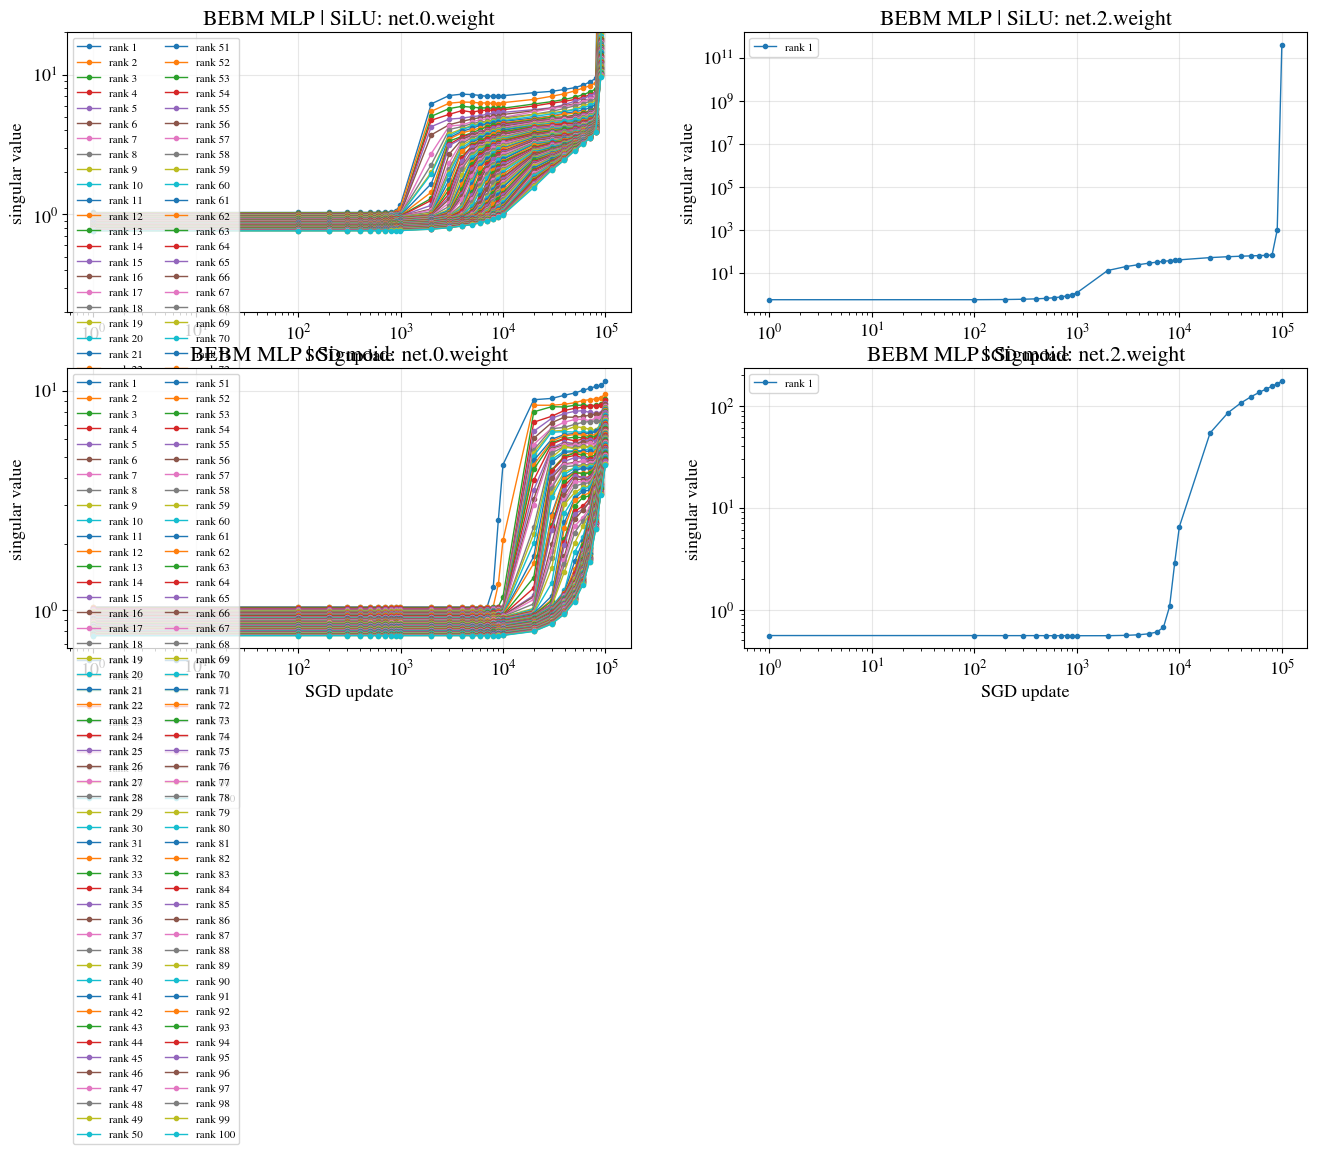

In [75]:
fig, axes = plt.subplots(len(MODEL_SPECS), 2, figsize=(16, 4 * len(MODEL_SPECS)), sharex=False)
if len(MODEL_SPECS) == 1:
    axes = axes[None, :]

for row, (label, hist) in enumerate(singular_history.items()):
    for col, key in enumerate(["net.0.weight", "net.2.weight"]):
        ax = axes[row, col]
        updates = hist["updates"]
        values = hist[key]
        n_rank = min(SINGULAR_TOP_K, values.shape[1])
        for rank in range(n_rank):
            ax.plot(updates, values[:, rank], marker=".", linewidth=1, label=f"rank {rank + 1}")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(alpha=0.3)
        ax.set_xlabel("SGD update")
        ax.set_ylabel("singular value")
        ax.set_title(f"{label}: {key}")
        if col == 0:
            ax.legend(ncol=2, fontsize=8)
        elif n_rank <= 3:
            ax.legend(fontsize=8)

axes[0,0].set_ylim(0, 20)
plt.tight_layout()
plt.show()


## Final W1 Filters


analysis updates: {'BEBM MLP | SiLU': 26915, 'BEBM MLP | Sigmoid': 100000}
BEBM MLP | SiLU update 26915 W1 (500, 784) b1 (500,)


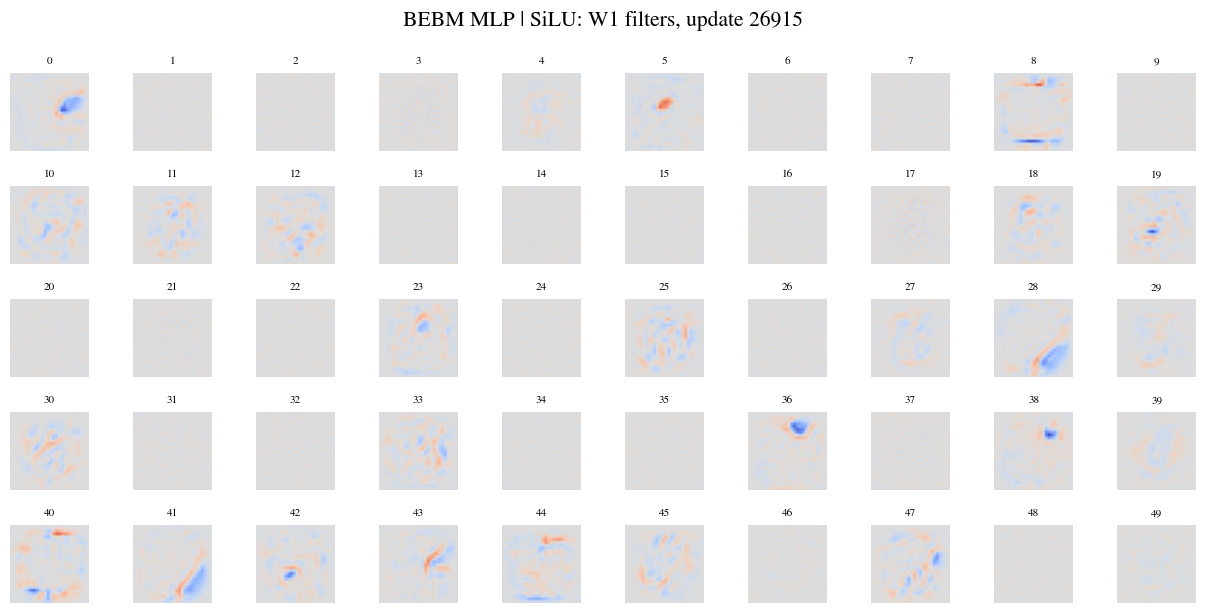

BEBM MLP | Sigmoid update 100000 W1 (500, 784) b1 (500,)


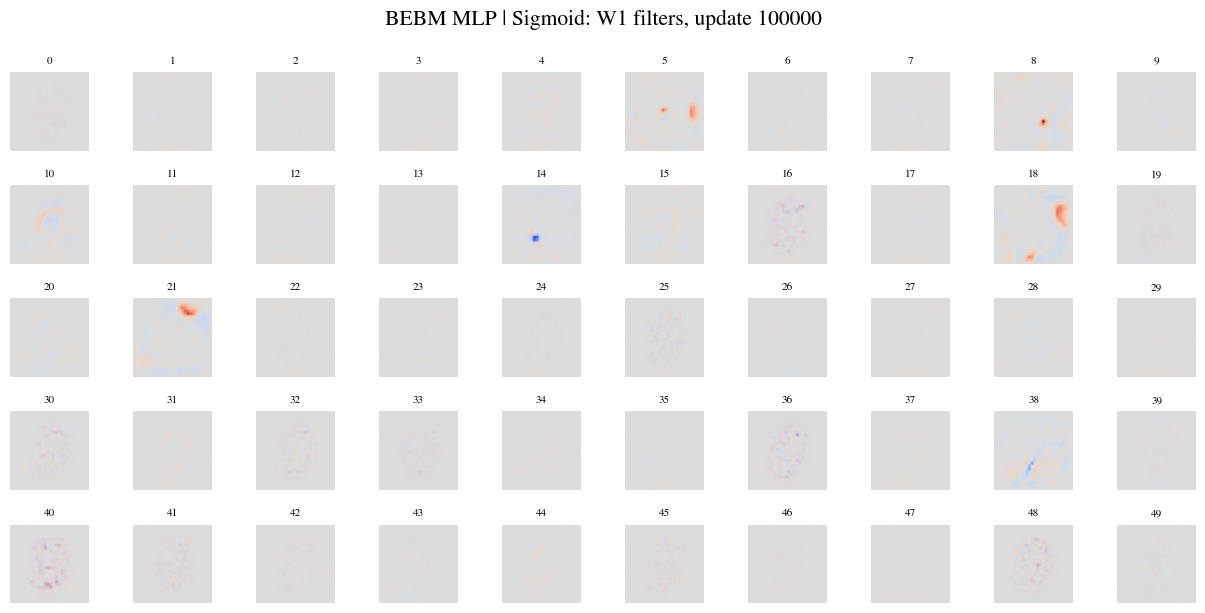

In [65]:
final_updates = {}
for label, updates in saved_updates_by_model.items():
    override = FINAL_UPDATE_OVERRIDES.get(label)
    if override is None:
        final_updates[label] = int(updates[-1])
    else:
        if override not in set(map(int, updates)):
            closest = int(updates[np.argmin(np.abs(updates - override))])
            print(f"{label}: requested update {override} not saved, using closest saved update {closest}")
            override = closest
        final_updates[label] = int(override)

print("analysis updates:", final_updates)

final_w1 = {}
final_b1 = {}

for label, spec in MODEL_SPECS.items():
    named = read_mlp_params_from_h5(spec["filename"], final_updates[label])
    final_w1[label] = named["net.0.weight"]
    final_b1[label] = named["net.0.bias"]
    print(label, "update", final_updates[label], "W1", final_w1[label].shape, "b1", final_b1[label].shape)
    plot_vector_grid(final_w1[label][:50], title=f"{label}: W1 filters, update {final_updates[label]}", n=50, cmap="coolwarm")


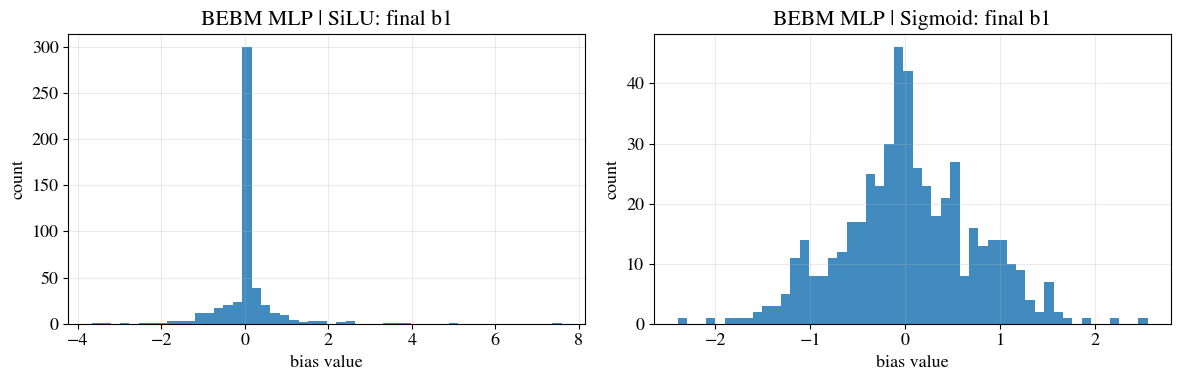

In [66]:
fig, axes = plt.subplots(1, len(MODEL_SPECS), figsize=(6 * len(MODEL_SPECS), 4), squeeze=False)
for ax, (label, b1) in zip(axes.ravel(), final_b1.items()):
    ax.hist(b1, bins=50, alpha=0.85)
    ax.set_title(f"{label}: final b1")
    ax.set_xlabel("bias value")
    ax.set_ylabel("count")
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Data PCA Basis


data_proj (60000, 784)


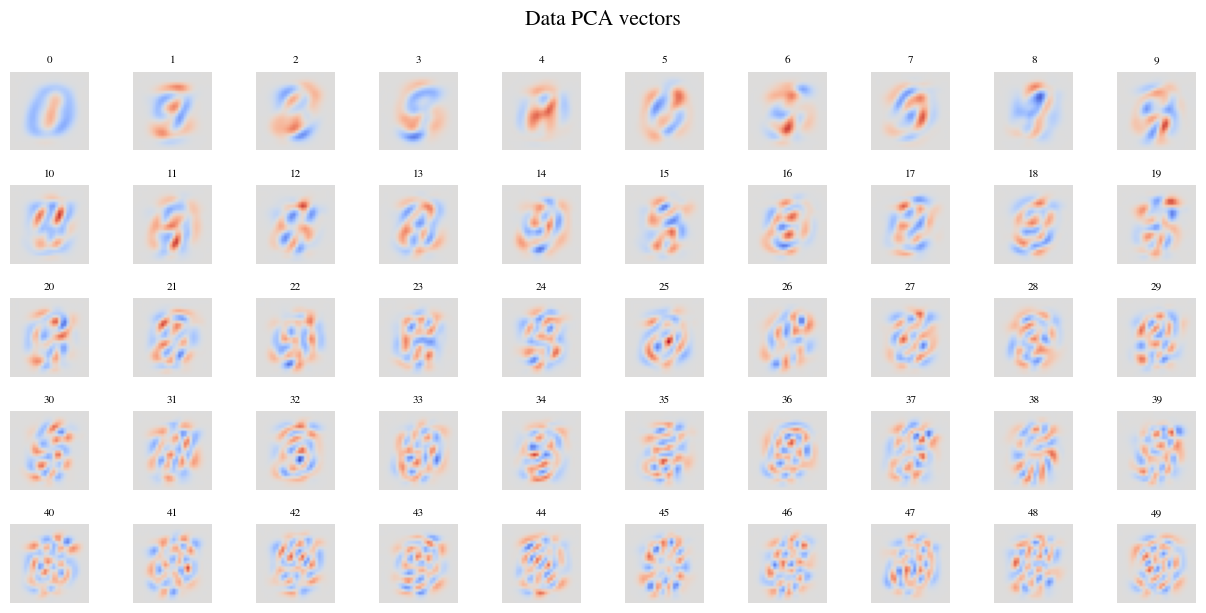

In [67]:
with torch.no_grad():
    data_mean = train_visible.mean(dim=0, keepdim=True)
    centered_data = train_visible - data_mean
    cov_data = centered_data.t() @ centered_data / max(1, train_visible.shape[0] - 1)
    eigvals_data, V_data = torch.linalg.eigh(cov_data)
    order = torch.argsort(eigvals_data, descending=True)
    eigvals_data = eigvals_data[order]
    V_data = V_data[:, order]
    V_dataT = V_data.t()

    data_proj = project_in_data_pca(train_visible).detach().cpu().numpy()

print("data_proj", data_proj.shape)
plot_vector_grid(V_data.detach().cpu().numpy().T[:50], title="Data PCA vectors", n=50, cmap="coolwarm")


## Final Permanent Chains in PCA Space


In [68]:
final_perm_proj = {}
final_perm_visible = {}

for label in MODEL_SPECS:
    final_update = final_updates[label]
    params, perm_chains, _ = load_model_with_activation(label, final_update)
    pc_proj = project_in_data_pca(perm_chains["visible"])

    final_perm_visible[label] = perm_chains["visible"].detach().cpu()
    final_perm_proj[label] = pc_proj.detach().cpu().numpy()

    print(label, "update", final_update, "chains", tuple(perm_chains["visible"].shape))


BEBM MLP | SiLU update 26915 chains (2048, 784)
BEBM MLP | Sigmoid update 100000 chains (2048, 784)


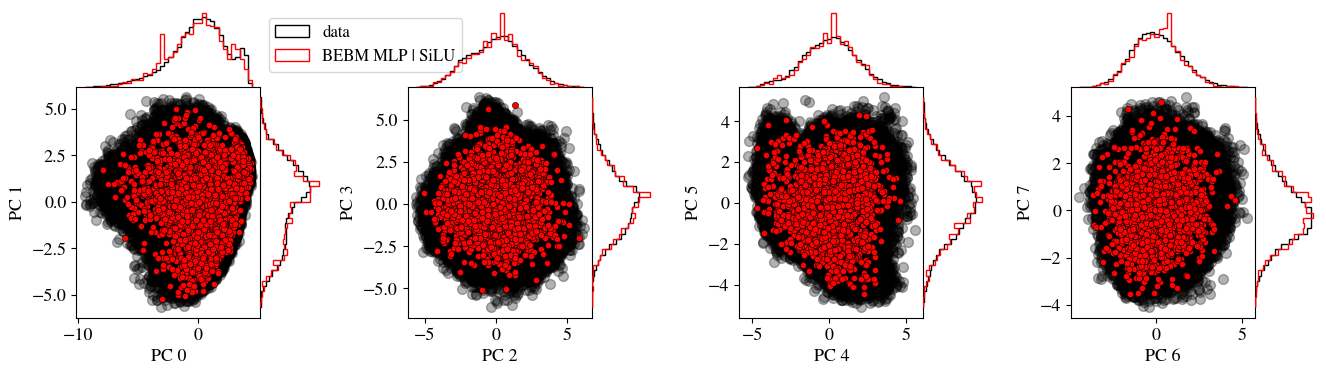

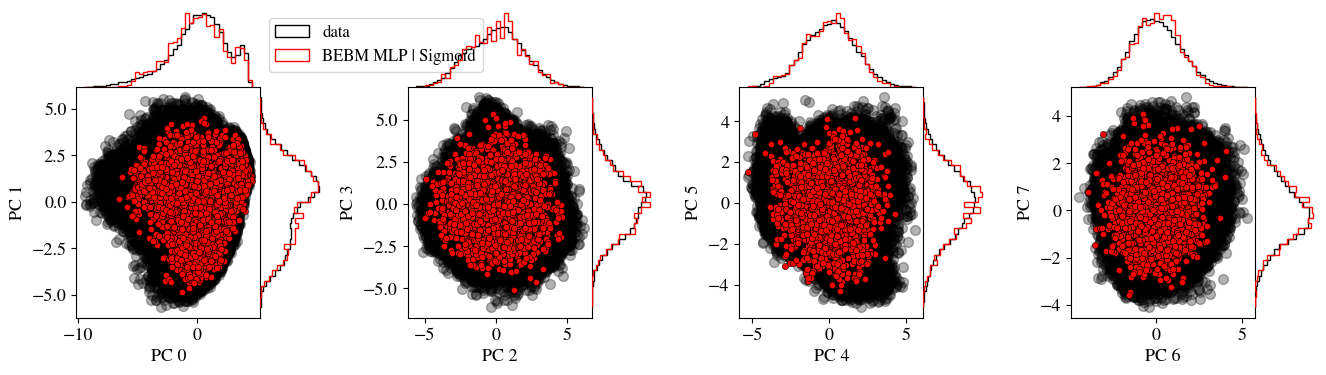

In [69]:
for label, pc_proj in final_perm_proj.items():
    plot_mult_PCA(
        data_proj[:, :8],
        pc_proj[:, :8],
        labels=["data", label],
    )


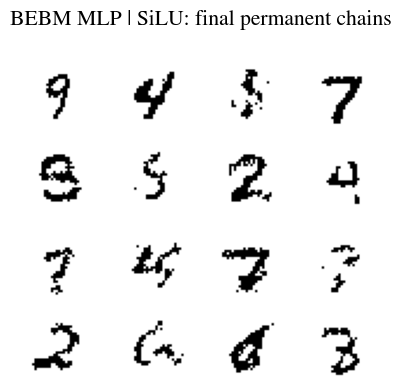

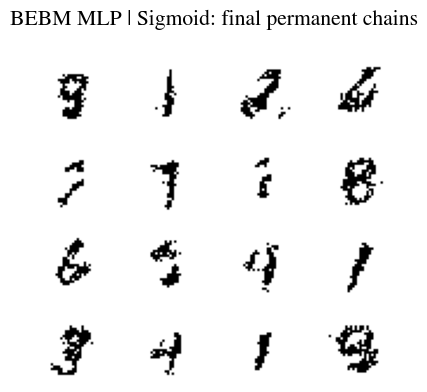

In [70]:
for label, visible in final_perm_visible.items():
    plot_binary_image_grid(visible=visible, title=f"{label}: final permanent chains", shape=IMAGE_SHAPE, grid_size=(4, 4))


## PCA of Generated Samples


BEBM MLP | SiLU final sample acceptance None


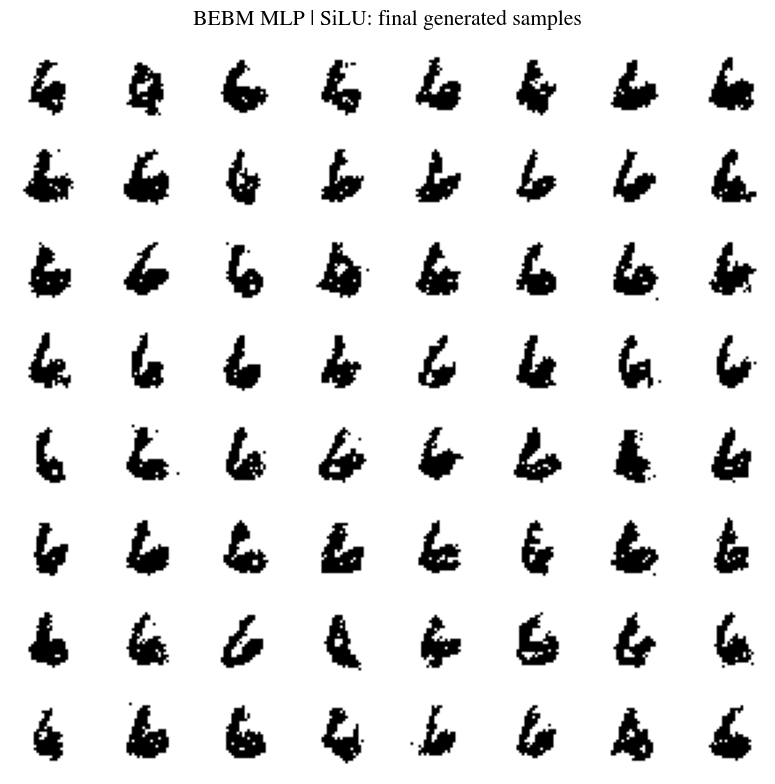

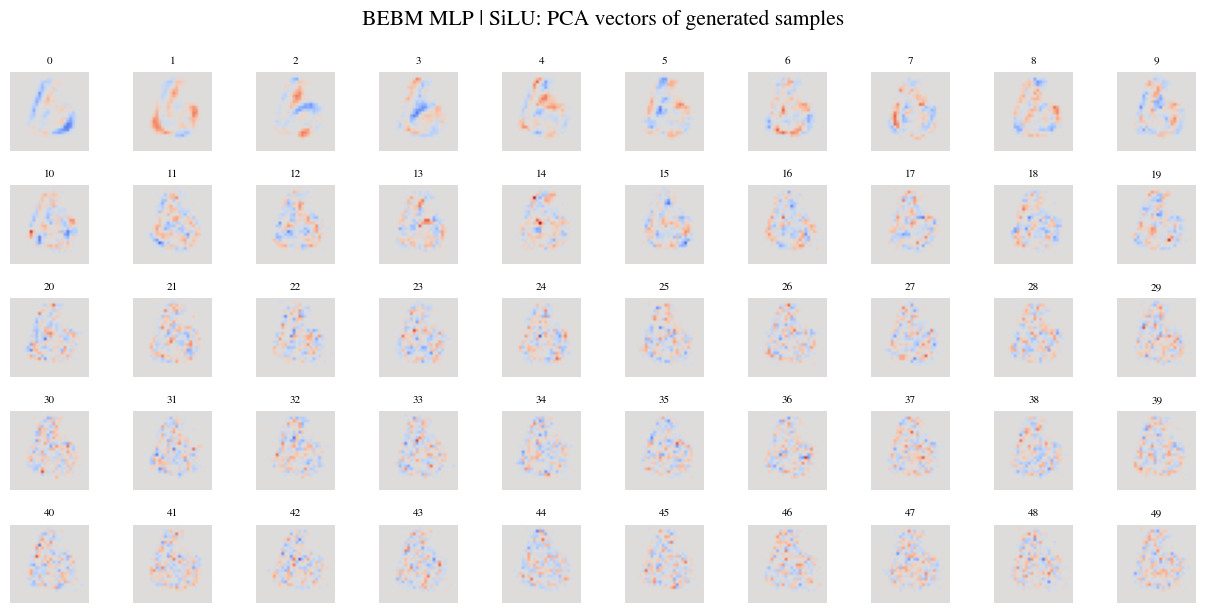

BEBM MLP | Sigmoid final sample acceptance None


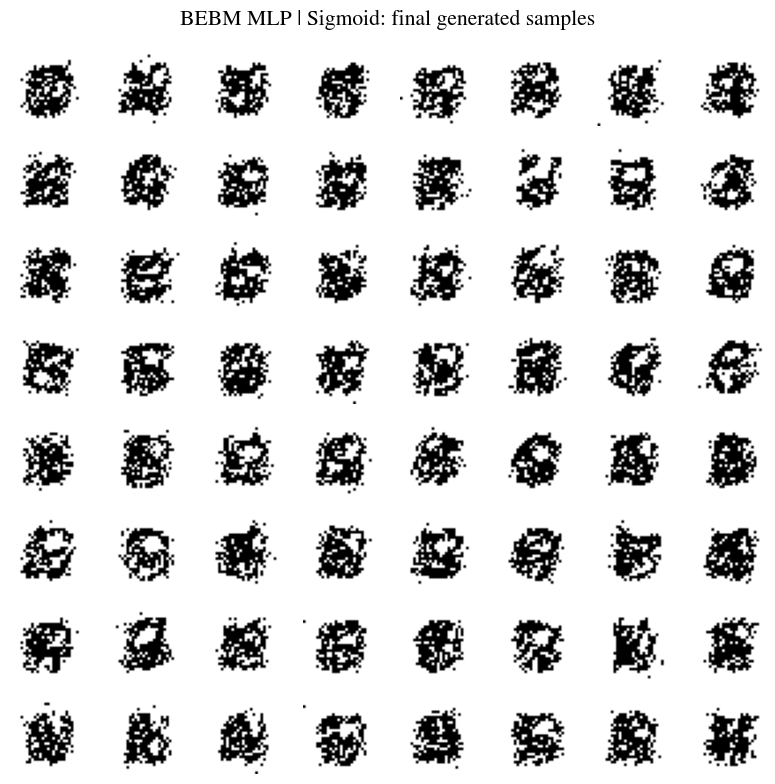

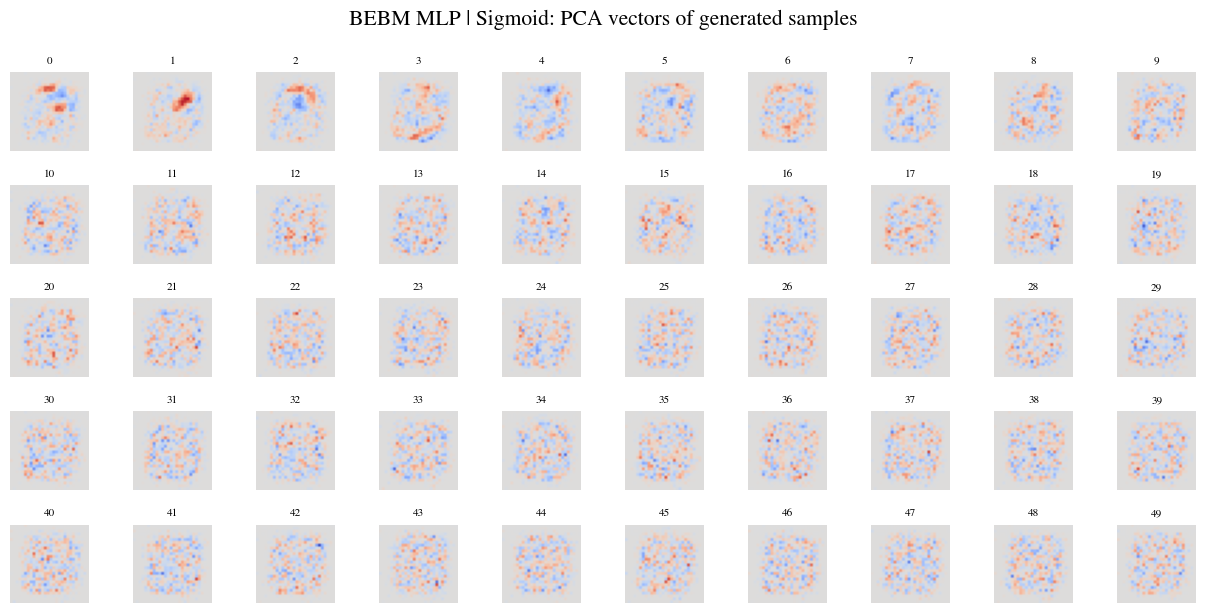

In [71]:
FINAL_SAMPLE_NUM_CHAINS = 128
FINAL_SAMPLE_STEPS = 100000
FINAL_SAMPLE_ALPHA = 0.5

model_generated_samples = {}
model_pca = {}

torch.manual_seed(123)
initial_visible_final = torch.bernoulli(torch.full((FINAL_SAMPLE_NUM_CHAINS, num_visibles), 0.5, device=device, dtype=dtype))

for label in MODEL_SPECS:
    params = load_params_with_activation(label, final_updates[label])
    visible, acceptance = sample_visible(params=params, initial_visible=initial_visible_final, num_steps=FINAL_SAMPLE_STEPS, alpha=FINAL_SAMPLE_ALPHA)
    model_generated_samples[label] = visible.detach().cpu()
    eigvals_model, eigvecs_model = pca_from_samples(visible)
    model_pca[label] = {"eigvals": eigvals_model, "eigvecs": eigvecs_model}
    print(label, "final sample acceptance", acceptance)
    plot_binary_image_grid(visible[:64], title=f"{label}: final generated samples", shape=IMAGE_SHAPE, grid_size=(8, 8))
    plot_vector_grid(eigvecs_model.T[:50], title=f"{label}: PCA vectors of generated samples", n=50, cmap="coolwarm")


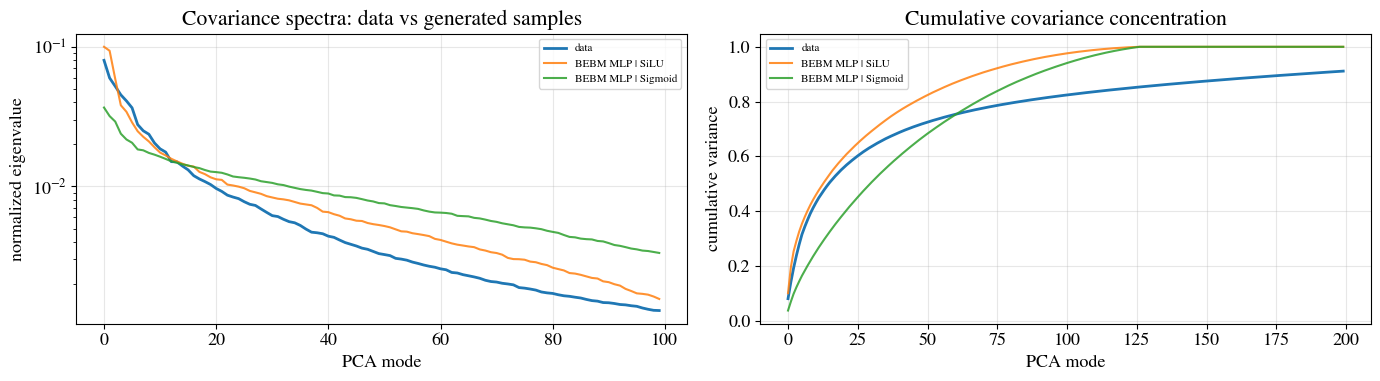

In [72]:
data_eigvals_np = eigvals_data.detach().cpu().numpy()
data_eigvals_norm = data_eigvals_np / data_eigvals_np.sum()
data_vecs_np = V_data.detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(data_eigvals_norm[:100], label="data", linewidth=2)
for label, result in model_pca.items():
    eig = result["eigvals"]
    eig = eig / eig.sum()
    axes[0].plot(eig[:100], label=label, alpha=0.85)
axes[0].set_yscale("log")
axes[0].set_xlabel("PCA mode")
axes[0].set_ylabel("normalized eigenvalue")
axes[0].set_title("Covariance spectra: data vs generated samples")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].plot(np.cumsum(data_eigvals_norm[:200]), label="data", linewidth=2)
for label, result in model_pca.items():
    eig = result["eigvals"]
    eig = eig / eig.sum()
    axes[1].plot(np.cumsum(eig[:200]), label=label, alpha=0.85)
axes[1].set_xlabel("PCA mode")
axes[1].set_ylabel("cumulative variance")
axes[1].set_title("Cumulative covariance concentration")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
